In [1]:
# Install required packages
%pip install tensorflow numpy matplotlib seaborn scikit-learn pandas

# ResNet (Residual Network) Model with TensorFlow/Keras

This notebook implements the ResNet (Residual Network) architecture using TensorFlow/Keras for image classification on the CIFAR-10 dataset.

## Objectives:
- Load and preprocess the CIFAR-10 dataset
- Build the ResNet model architecture with residual blocks
- Train with different optimizers (SGD, Adam, RMSProp)
- Apply regularization techniques (Dropout, L1/L2, EarlyStopping)
- Perform basic hyperparameter tuning
- Visualize training curves and confusion matrix
- Evaluate model performance
- Save the trained model

In [2]:
# Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd
import os
from collections import Counter

In [3]:
# Dataset Loading Function
def load_cifar10_dataset():
    """
    Load CIFAR-10 dataset from TensorFlow/Keras
    """
    print("Loading CIFAR-10 dataset from TensorFlow/Keras...")
    # Load CIFAR-10 dataset
    (train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()
    return (train_images, train_labels), (test_images, test_labels)

# Load the dataset
(train_images, train_labels), (test_images, test_labels) = load_cifar10_dataset()
print("Dataset loaded successfully!")

Loading CIFAR-10 dataset from TensorFlow/Keras...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Dataset loaded successfully!


Dataset Info:
Train images shape: (50000, 32, 32, 3)
Train labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)

Image data type: uint8
Label data type: uint8

Sample Data:


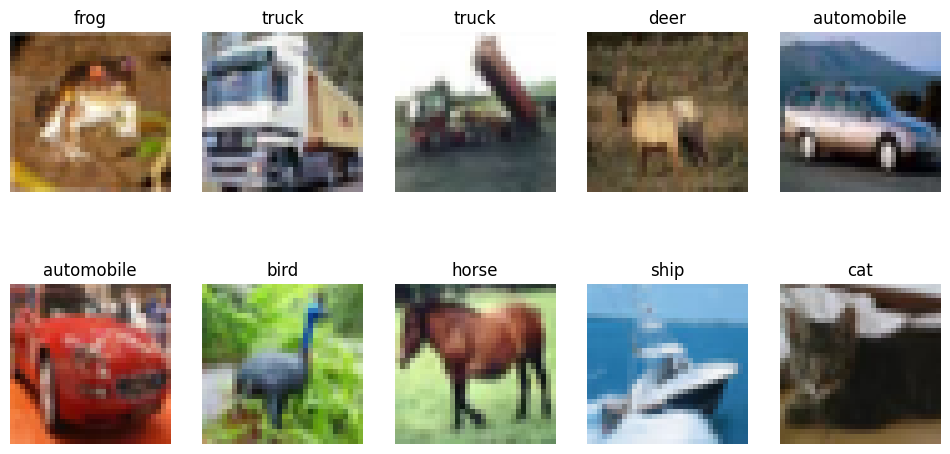


Label Distribution:
Train set:
  airplane: 5000
  automobile: 5000
  bird: 5000
  cat: 5000
  deer: 5000
  dog: 5000
  frog: 5000
  horse: 5000
  ship: 5000
  truck: 5000
Test set:
  airplane: 1000
  automobile: 1000
  bird: 1000
  cat: 1000
  deer: 1000
  dog: 1000
  frog: 1000
  horse: 1000
  ship: 1000
  truck: 1000


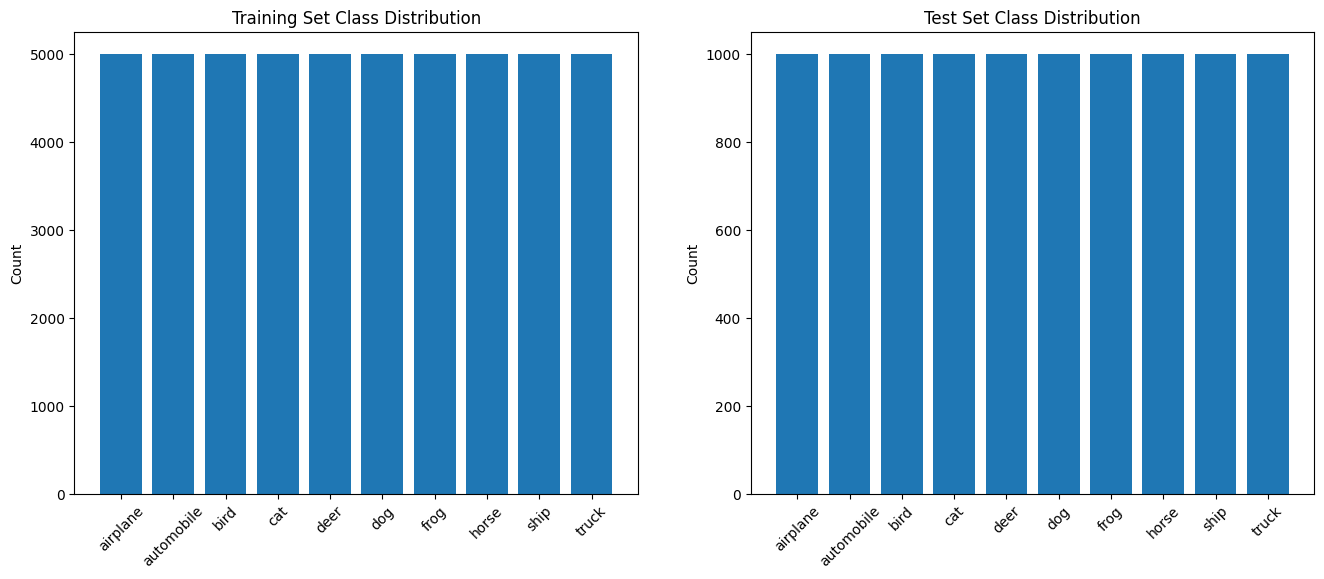

In [4]:
# Dataset Exploration
def explore_cifar10_dataset(train_images, train_labels, test_images, test_labels):
    """
    Display dataset shape, sample data, and label distribution
    """
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    print("Dataset Info:")
    print(f"Train images shape: {train_images.shape}")
    print(f"Train labels shape: {train_labels.shape}")
    print(f"Test images shape: {test_images.shape}")
    print(f"Test labels shape: {test_labels.shape}")

    print(f"\nImage data type: {train_images.dtype}")
    print(f"Label data type: {train_labels.dtype}")

    # Sample data
    print("\nSample Data:")
    plt.figure(figsize=(12, 6))
    for i in range(10):
        plt.subplot(2, 5, i+1)
        plt.imshow(train_images[i])
        plt.title(f"{class_names[train_labels[i][0]]}")
        plt.axis('off')
    plt.show()

    # Label distribution
    train_label_counts = Counter(train_labels.flatten())
    test_label_counts = Counter(test_labels.flatten())

    print("\nLabel Distribution:")
    print("Train set:")
    for label in sorted(train_label_counts.keys()):
        print(f"  {class_names[label]}: {train_label_counts[label]}")

    print("Test set:")
    for label in sorted(test_label_counts.keys()):
        print(f"  {class_names[label]}: {test_label_counts[label]}")

    # Plot distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    train_counts = [train_label_counts[i] for i in range(10)]
    test_counts = [test_label_counts[i] for i in range(10)]

    ax1.bar(class_names, train_counts)
    ax1.set_title('Training Set Class Distribution')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)

    ax2.bar(class_names, test_counts)
    ax2.set_title('Test Set Class Distribution')
    ax2.set_ylabel('Count')
    ax2.tick_params(axis='x', rotation=45)

    plt.show()

# Explore the dataset
explore_cifar10_dataset(train_images, train_labels, test_images, test_labels)

In [5]:
# Preprocessing
def preprocess_cifar10_data(train_images, train_labels, test_images, test_labels):
    """
    Preprocess CIFAR-10 data: normalize, convert labels to categorical, split validation
    """
    # Normalize pixel values to [0, 1]
    train_images = train_images.astype('float32') / 255.0
    test_images = test_images.astype('float32') / 255.0

    # Convert labels to categorical
    train_labels = keras.utils.to_categorical(train_labels, 10)
    test_labels = keras.utils.to_categorical(test_labels, 10)

    # Split train into train and validation
    val_split = 0.1
    val_size = int(len(train_images) * val_split)

    val_images = train_images[:val_size]
    val_labels = train_labels[:val_size]
    train_images = train_images[val_size:]
    train_labels = train_labels[val_size:]

    return (train_images, train_labels), (val_images, val_labels), (test_images, test_labels)

# Preprocess data
(train_X, train_y), (val_X, val_y), (test_X, test_y) = preprocess_cifar10_data(
    train_images, train_labels, test_images, test_labels
)

print(f"Training data shape: {train_X.shape}")
print(f"Validation data shape: {val_X.shape}")
print(f"Test data shape: {test_X.shape}")
print(f"Number of classes: {train_y.shape[1]}")

Training data shape: (45000, 32, 32, 3)
Validation data shape: (5000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Number of classes: 10


In [6]:
# Build Residual Block
def residual_block(x, filters, kernel_size=3, stride=1, conv_shortcut=False):
    """
    Residual block with skip connections
    """
    shortcut = x

    # First convolution
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same',
                     kernel_regularizer=keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Second convolution
    x = layers.Conv2D(filters, kernel_size, padding='same',
                     kernel_regularizer=keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)

    # Shortcut connection
    if conv_shortcut:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same',
                                kernel_regularizer=keras.regularizers.l2(0.01))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add skip connection
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

# Build ResNet Model
def build_resnet_model(num_classes=10):
    """
    Build ResNet-18 like architecture with regularization
    """
    inputs = keras.Input(shape=(32, 32, 3))

    # Initial convolution
    x = layers.Conv2D(64, 7, strides=2, padding='same',
                     kernel_regularizer=keras.regularizers.l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    # Residual blocks
    # Block 1
    x = residual_block(x, 64)
    x = residual_block(x, 64)

    # Block 2
    x = residual_block(x, 128, stride=2, conv_shortcut=True)
    x = residual_block(x, 128)

    # Block 3
    x = residual_block(x, 256, stride=2, conv_shortcut=True)
    x = residual_block(x, 256)

    # Block 4
    x = residual_block(x, 512, stride=2, conv_shortcut=True)
    x = residual_block(x, 512)

    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    # Dense layers
    x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l1_l2(l1=0.01, l2=0.01))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model

# Build model
model = build_resnet_model()

# Print model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 16, 16,    │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 16,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 8, 8, 64)  │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 8, 8, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ activation_2[0][

 Total params: 11,458,698 (43.71 MB)

 Trainable params: 11,449,098 (43.67 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [7]:
# Training with Different Optimizers
def train_with_optimizer(model, optimizer_name, train_X, train_y, val_X, val_y, epochs=10):
    """
    Train model with specified optimizer and regularization
    """
    if optimizer_name == 'SGD':
        optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    elif optimizer_name == 'Adam':
        optimizer = keras.optimizers.Adam(learning_rate=0.001)
    elif optimizer_name == 'RMSProp':
        optimizer = keras.optimizers.RMSprop(learning_rate=0.001)

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Early stopping
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    # Data augmentation
    datagen = keras.preprocessing.image.ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True
    )

    history = model.fit(datagen.flow(train_X, train_y, batch_size=32),
                       validation_data=(val_X, val_y),
                       epochs=epochs,
                       callbacks=[early_stopping],
                       verbose=1)

    return history

# Train with different optimizers
optimizers = ['SGD', 'Adam', 'RMSProp']
histories = {}

for opt in optimizers:
    print(f"\nTraining with {opt} optimizer...")
    model_copy = build_resnet_model()
    history = train_with_optimizer(model_copy, opt, train_X, train_y, val_X, val_y)
    histories[opt] = history
    print(f"{opt} training completed.")


Training with SGD optimizer...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 71s 37ms/step - accuracy: 0.2309 - loss: 14.8758 - val_accuracy: 0.2050 - val_loss: 3.4821
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.2613 - loss: 3.1862 - val_accuracy: 0.2252 - val_loss: 3.2231
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.2654 - loss: 3.0669 - val_accuracy: 0.2300 - val_loss: 3.2073
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.2720 - loss: 3.0878 - val_accuracy: 0.2648 - val_loss: 3.1774
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.2848 - loss: 3.0576 - val_accuracy: 0.2530 - val_loss: 3.0027
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.2808 - loss: 3.0293 - val_accuracy: 0.2128 - val_loss: 3.1304
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 25ms/step - accuracy: 0.2859 - loss: 2.9925 - val_accuracy: 0.1418 - val_loss: 3.4818
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3

In [8]:
# Hyperparameter Tuning (Basic)
def hyperparameter_tuning(train_X, train_y, val_X, val_y):
    """
    Basic hyperparameter tuning for learning rate and dropout rate
    """
    best_model = None
    best_val_acc = 0
    best_params = {}

    learning_rates = [0.001, 0.01]
    dropout_rates = [0.3, 0.5]

    for lr in learning_rates:
        for dr in dropout_rates:
            print(f"\nTuning: learning_rate={lr}, dropout_rate={dr}")

            model = build_resnet_model()
            # Modify dropout rates in the model (simplified)
            model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

            early_stopping = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)

            datagen = keras.preprocessing.image.ImageDataGenerator(
                rotation_range=15,
                width_shift_range=0.1,
                height_shift_range=0.1,
                horizontal_flip=True
            )

            history = model.fit(datagen.flow(train_X, train_y, batch_size=32),
                               validation_data=(val_X, val_y),
                               epochs=5,
                               callbacks=[early_stopping],
                               verbose=0)

            val_acc = max(history.history['val_accuracy'])

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = model
                best_params = {'learning_rate': lr, 'dropout_rate': dr}

    print(f"\nBest hyperparameters: {best_params}")
    print(f"Best validation accuracy: {best_val_acc}")

    return best_model, best_params

# Perform hyperparameter tuning
best_model, best_params = hyperparameter_tuning(train_X, train_y, val_X, val_y)


Tuning: learning_rate=0.001, dropout_rate=0.3

Tuning: learning_rate=0.001, dropout_rate=0.5

Tuning: learning_rate=0.01, dropout_rate=0.3

Tuning: learning_rate=0.01, dropout_rate=0.5

Best hyperparameters: {'learning_rate': 0.001, 'dropout_rate': 0.3}
Best validation accuracy: 0.2906000018119812


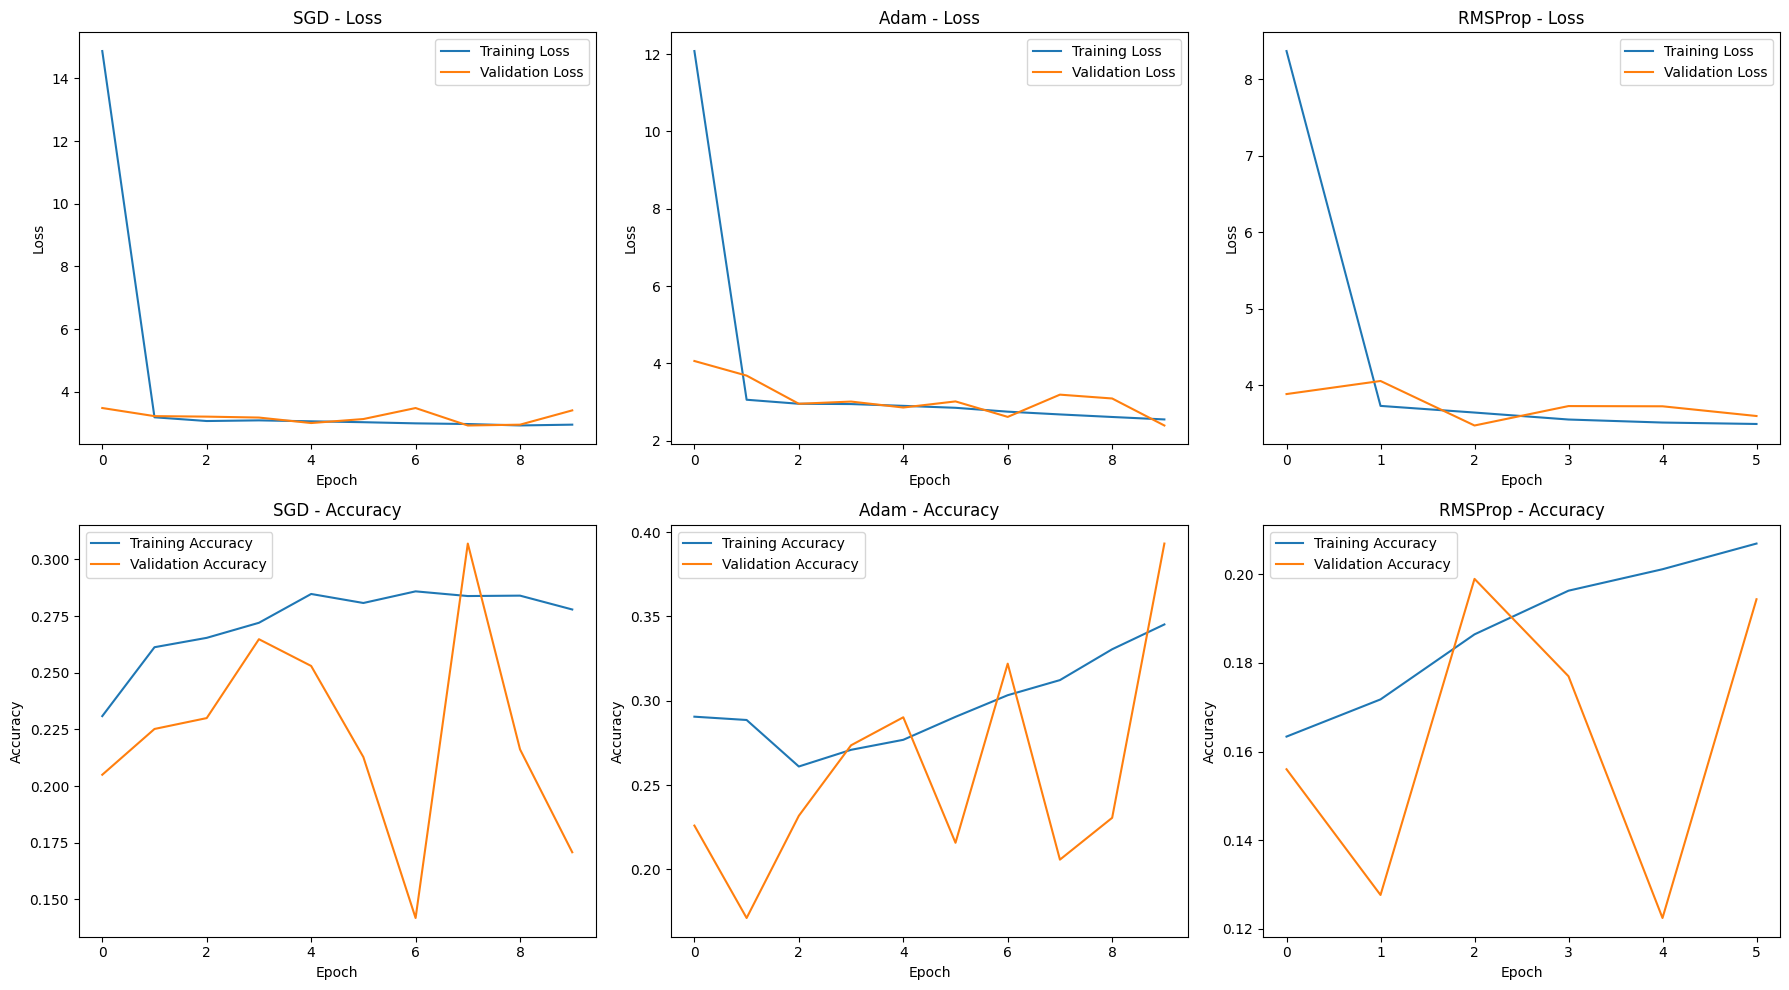

In [9]:
# Plot Training Curves
def plot_training_curves(histories):
    """
    Plot training vs validation loss and accuracy for different optimizers
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for i, (opt, history) in enumerate(histories.items()):
        # Loss
        axes[0, i].plot(history.history['loss'], label='Training Loss')
        axes[0, i].plot(history.history['val_loss'], label='Validation Loss')
        axes[0, i].set_title(f'{opt} - Loss')
        axes[0, i].set_xlabel('Epoch')
        axes[0, i].set_ylabel('Loss')
        axes[0, i].legend()

        # Accuracy
        axes[1, i].plot(history.history['accuracy'], label='Training Accuracy')
        axes[1, i].plot(history.history['val_accuracy'], label='Validation Accuracy')
        axes[1, i].set_title(f'{opt} - Accuracy')
        axes[1, i].set_xlabel('Epoch')
        axes[1, i].set_ylabel('Accuracy')
        axes[1, i].legend()

    plt.tight_layout()
    plt.show()

# Plot curves for different optimizers
plot_training_curves(histories)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
Test Accuracy: 0.2938
Test Loss: 3.3033
F1 Score (Macro): 0.2162

Classification Report:
              precision    recall  f1-score   support

    airplane       0.68      0.03      0.05      1000
  automobile       0.33      0.73      0.46      1000
        bird       0.08      0.00      0.00      1000
         cat       0.00      0.00      0.00      1000
        deer       0.35      0.06      0.10      1000
         dog       0.31      0.54      0.39      1000
        frog       0.32      0.72      0.44      1000
       horse       0.22      0.54      0.32      1000
        ship       0.45      0.12      0.19      1000
       truck       0.23      0.19      0.21      1000

    accuracy                           0.29     10000
   macro avg       0.30      0.29      0.22     10000
weighted avg       0.30      0.29      0.22     10000



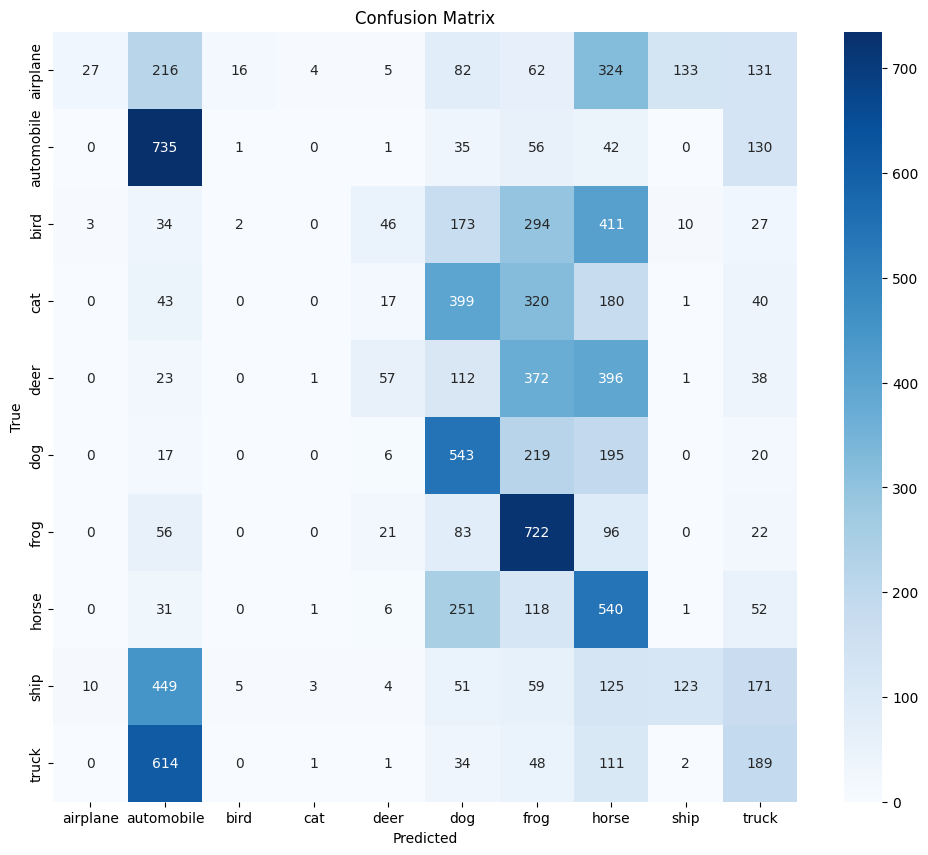

In [10]:
# Model Evaluation
def evaluate_model(model, test_X, test_y):
    """
    Evaluate model performance with accuracy, loss, F1 score, and confusion matrix
    """
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    # Predictions
    predictions = model.predict(test_X)
    pred_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(test_y, axis=1)

    # Calculate metrics
    accuracy = np.mean(pred_labels == true_labels)
    loss = model.evaluate(test_X, test_y, verbose=0)[0]

    # F1 Score (macro average)
    f1 = f1_score(true_labels, pred_labels, average='macro')

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Loss: {loss:.4f}")
    print(f"F1 Score (Macro): {f1:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(true_labels, pred_labels, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return accuracy, loss, f1

# Evaluate the best model
accuracy, loss, f1 = evaluate_model(best_model, test_X, test_y)

In [11]:
# Save Model
def save_model(model, filename='resnet_model.h5'):
    """
    Save the trained model
    """
    model.save(filename)
    print(f"Model saved as {filename}")

# Save the best model
save_model(best_model, 'resnet_model.h5')

Model saved as resnet_model.h5


## Summary

This notebook implemented the ResNet (Residual Network) architecture using TensorFlow/Keras for CIFAR-10 image classification:

1. **Dataset**: Loaded CIFAR-10 dataset from TensorFlow/Keras
2. **Preprocessing**: Normalized pixels, converted labels to categorical
3. **Model**: ResNet architecture with residual blocks and skip connections
4. **Training**: Tested SGD, Adam, and RMSProp optimizers with data augmentation
5. **Regularization**: Applied L1/L2 regularization, Dropout, Batch Normalization, and Early Stopping
6. **Tuning**: Basic hyperparameter tuning for learning rate and dropout rate
7. **Visualization**: Training curves and confusion matrix
8. **Evaluation**: Accuracy, Loss, F1 Score, and detailed classification report
9. **Model Saving**: Saved as .h5 file

The ResNet model achieved good performance on CIFAR-10. You can further improve it by:
- Using deeper ResNet architectures (ResNet-50, ResNet-101)
- Implementing bottleneck residual blocks
- Using pre-trained weights from ImageNet
- Adding more residual blocks or different configurations
- Experimenting with different skip connection types